In [1]:
import lightning.pytorch as pl
from lightning.pytorch.profilers import PyTorchProfiler
from torch.profiler import schedule
import os
import tempfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import optuna
import pandas as pd
from collections import Counter
import torchvision.models as tv_models
import time
import numpy as np
from pathlib import Path
import sys

In [2]:
# Move working directory to the project root if this notebook is opened from notebooks/
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())

Current working directory: /Users/fujimotodai/Desktop/plant-disease-diagnosis-assistant


In [3]:
from src.models import FlexibleCNN, fine_tuning_stage1, fine_tuning_stage2
from src.image_inference import predict_image
from src.diagnosis import parse_class_name, build_diagnosis, generate_explanation, load_disease_database
from src.intent_classifier import predict_intent
from src.qa import answer_user_question

In [4]:
print(os.listdir("PlantVillage-Dataset"))
!find PlantVillage-Dataset -maxdepth 2 -type d | head -30

['leaf_grouping', 'plant_village.py', 'generate_lmdb.sh', 'leaf-map.json', '.DS_Store', 'data_distribution_for_SVM', 'generate_mapstring.py', 'CITATION.cff', 'utils', 'README.md', 'logs', '.gitignore', 'scripts', 'PlantVillage-Dataset', 'generate_data_for_SVM.py', 'README_HF.md', '.git', 'generated_for_paper', 'raw']


In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using Device: CUDA")
elif torch.mps.is_available():
    device = torch.device("mps")
    print("Using Device: MPS")
else:
    device = torch.device("cpu")
    print("Using Device: CPU")

Using Device: MPS


In [8]:
def download_dataset(image_dir):
    raw_dataset = datasets.ImageFolder(root=image_dir, transform=None)
    
    num_classes = len(raw_dataset.classes)
    print(f"Image Num: {len(raw_dataset)}")
    print(f"Class Num: {num_classes}")
    print(raw_dataset.class_to_idx)
    
    return raw_dataset, num_classes

image_dir = "PlantVillage-Dataset/raw/color"
raw_dataset, num_classes = download_dataset(image_dir = image_dir)

Image Num: 54305
Class Num: 38
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tom

In [9]:
def split_dataset(dataset, val_fraction, test_fraction):
    full_size = len(dataset)
    val_size = int(full_size * val_fraction)
    test_size = int(full_size * test_fraction)
    train_size = full_size - val_size - test_size
    
    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
    print(f"Train Size: {train_size}")
    print(f"Val Size: {val_size}")
    print(f"Test Size: {test_size}")
    
    return train_dataset, val_dataset, test_dataset

train_subset, val_subset, test_subset = split_dataset(dataset=raw_dataset, val_fraction=0.15, test_fraction=0.15)

Train Size: 38015
Val Size: 8145
Test Size: 8145


In [10]:
class_counts = Counter(raw_dataset.targets)

df_counts = pd.DataFrame({
    "class_idx": list(class_counts.keys()),
    "class_name": [
        raw_dataset.classes[i]
        for i in class_counts.keys()
    ],
    "count": list(class_counts.values())
})

df_counts = df_counts.sort_values(
    "count",
    ascending=False
).reset_index(drop=True)

display(df_counts)

,class_idx,class_name,count
0,15,Orange___Haunglongbing_(Citrus_greening),5507
1,35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
2,24,Soybean___healthy,5090
3,16,Peach___Bacterial_spot,2297
4,28,Tomato___Bacterial_spot,2127
5,30,Tomato___Late_blight,1909
6,25,Squash___Powdery_mildew,1835
7,32,Tomato___Septoria_leaf_spot,1771
8,33,Tomato___Spider_mites Two-spotted_spider_mite,1676
9,3,Apple___healthy,1645


In [11]:
def get_transforms(image_size, mean, std):
    resize_size = int(image_size * 1.15)

    train_transform = transforms.Compose([
        transforms.Resize(resize_size),
        transforms.CenterCrop(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    eval_transform = transforms.Compose([
        transforms.Resize(resize_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    return train_transform, eval_transform

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
train_transforms, test_transforms = get_transforms(image_size=128, mean=mean, std=std)
train_transforms_for_pm, test_transforms_for_pm = get_transforms(image_size=224, mean=mean, std=std)

In [12]:
class SubsetWithTransform(Dataset):
    def __init__(self, subset, transforms):
        self.subset = subset
        self.transforms = transforms
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transforms:
            image = self.transforms(image)
        
        return image, label

train_dataset = SubsetWithTransform(train_subset, train_transforms)
val_dataset = SubsetWithTransform(val_subset, test_transforms)
test_dataset = SubsetWithTransform(test_subset, test_transforms)

# ResNet / MobileNet: 224 × 224
train_dataset_for_pm = SubsetWithTransform(train_subset, train_transforms_for_pm)
val_dataset_for_pm = SubsetWithTransform(val_subset, test_transforms_for_pm)
test_dataset_for_pm = SubsetWithTransform(test_subset, test_transforms_for_pm)

batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

train_loader_for_pm = DataLoader(dataset=train_dataset_for_pm, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_for_pm = DataLoader(dataset=val_dataset_for_pm, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader_for_pm = DataLoader(dataset=test_dataset_for_pm, batch_size=batch_size, shuffle=False, num_workers=0)

In [17]:
import inspect

print(inspect.getfile(FlexibleCNN))

/Users/fujimotodai/Desktop/plant-disease-diagnosis-assistant/src/models.py


In [19]:
def train_loop_for_tuning(train_loader, model, device, optimizer, loss_function, n_epochs):
    train_loss = []
    model.train()
    for i in range(n_epochs):
        running_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * len(labels)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        train_loss.append(epoch_loss)
        print(f"Epoch [{i + 1}/{n_epochs}], Training Loss: {epoch_loss:.4f}")
    return train_loss

In [20]:
def evaluate_for_tuning(val_loader, model, device, loss_function, num_classes):
    running_val_loss = 0
    val_accuracy = 0
    accuracy = torchmetrics.Accuracy(
        task="multiclass", 
        num_classes=num_classes, 
        average="macro"
    ).to(device)
    model.eval()
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            _, predicted = outputs.max(1)
            
            running_val_loss += loss.item() * len(labels)
            accuracy.update(predicted, labels)
        
        val_loss = running_val_loss / len(val_loader.dataset)
        val_accuracy = accuracy.compute().item()
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {100*val_accuracy:.2f}%")
        print("===============================================================")
        
    return val_loss, val_accuracy

In [21]:
#training hyperparameter tuning
def objective_architecture(trial, device, train_loader, val_loader):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    n_filters = [trial.suggest_int(f"n_filters_{i}", 16, 64) for i in range(n_layers)]
    kernel_sizes = [trial.suggest_categorical(f"kernel_sizes_{i}", [3, 5]) for i in range(n_layers)]
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    fc_size = trial.suggest_int("fc_size", 64, 256)
    
    batch_size = 64
    
    model = FlexibleCNN(
        n_layers=n_layers, 
        n_filters=n_filters,
        kernel_sizes=kernel_sizes, 
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        fc_size=fc_size,
        num_classes=38
    ).to(device)

    dummy = torch.randn(1, 3, 128, 128).to(device)
    model(dummy)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_function = nn.CrossEntropyLoss()
    
    n_epochs = 5
    
    train_loss = train_loop_for_tuning(
        train_loader=train_loader,
        model=model,
        device = device,
        optimizer=optimizer,
        loss_function=loss_function,
        n_epochs=n_epochs
    )
    
    val_loss, val_accuracy = evaluate_for_tuning(
        val_loader=val_loader,
        model=model,
        device=device,
        loss_function=loss_function,
        num_classes=38
    )
    
    return val_accuracy

In [189]:
study = optuna.create_study(direction="maximize")
n_trials = 25
study.optimize(lambda trial: objective_architecture(trial, device, train_loader, val_loader), n_trials=n_trials)

[I 2026-07-09 03:08:40,167] A new study created in memory with name: no-name-067c7e77-0e6c-44d3-91bd-964ad1fa8102


Epoch [1/5], Training Loss: 2.0798
Epoch [2/5], Training Loss: 1.2942
Epoch [3/5], Training Loss: 1.0539
Epoch [4/5], Training Loss: 0.8927
Epoch [5/5], Training Loss: 0.7880


[I 2026-07-09 03:21:04,069] Trial 0 finished with value: 0.8234989047050476 and parameters: {'n_layers': 3, 'n_filters_0': 23, 'n_filters_1': 62, 'n_filters_2': 61, 'kernel_sizes_0': 5, 'kernel_sizes_1': 3, 'kernel_sizes_2': 3, 'dropout_rate': 0.38737958805151534, 'fc_size': 119}. Best is trial 0 with value: 0.8234989047050476.


Val Loss: 0.4355, Val Accuracy: 82.35%
Epoch [1/5], Training Loss: 2.4014
Epoch [2/5], Training Loss: 1.6079
Epoch [3/5], Training Loss: 1.3634
Epoch [4/5], Training Loss: 1.2182
Epoch [5/5], Training Loss: 1.1097


[I 2026-07-09 03:34:45,292] Trial 1 finished with value: 0.7156651020050049 and parameters: {'n_layers': 3, 'n_filters_0': 24, 'n_filters_1': 45, 'n_filters_2': 33, 'kernel_sizes_0': 3, 'kernel_sizes_1': 5, 'kernel_sizes_2': 3, 'dropout_rate': 0.434735698234706, 'fc_size': 64}. Best is trial 0 with value: 0.8234989047050476.


...

Val Loss: 0.2811, Val Accuracy: 89.34%
Epoch [1/5], Training Loss: 1.7291
Epoch [2/5], Training Loss: 0.7357
Epoch [3/5], Training Loss: 0.5124
Epoch [4/5], Training Loss: 0.4110
Epoch [5/5], Training Loss: 0.3445


[I 2026-07-09 19:52:52,239] Trial 14 finished with value: 0.9044514894485474 and parameters: {'n_layers': 4, 'n_filters_0': 52, 'n_filters_1': 53, 'n_filters_2': 47, 'n_filters_3': 64, 'kernel_sizes_0': 5, 'kernel_sizes_1': 3, 'kernel_sizes_2': 3, 'kernel_sizes_3': 5, 'dropout_rate': 0.18254060741389366, 'fc_size': 254}. Best is trial 14 with value: 0.9044514894485474.


Val Loss: 0.2532, Val Accuracy: 90.45%


[W 2026-07-09 20:25:34,656] Trial 15 failed with parameters: {'n_layers': 3, 'n_filters_0': 53, 'n_filters_1': 46, 'n_filters_2': 48, 'kernel_sizes_0': 5, 'kernel_sizes_1': 3, 'kernel_sizes_2': 3, 'dropout_rate': 0.1568260225916783, 'fc_size': 250} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/p7/6qgd2k357mb4c9jgwkm_pjw40000gn/T/ipykernel_68098/675973686.py", line 3, in <lambda>
    study.optimize(lambda trial: objective(trial, device, train_loader, val_loader), n_trials=n_trials)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/p7/6qgd2k357mb4c9jgwkm_pjw40000gn/T/ipykernel_68098/3347422032.py", line 28, in objective
    train_loss = train_loop(
                 ^^^^^^^^^^^
  File "/var/folders/p7/6q

KeyboardInterrupt: 

In [190]:
df = study.trials_dataframe()
df

,number,value,datetime_start,datetime_complete,duration,params_dropout_rate,params_fc_size,params_kernel_sizes_0,params_kernel_sizes_1,params_kernel_sizes_2,params_kernel_sizes_3,params_n_filters_0,params_n_filters_1,params_n_filters_2,params_n_filters_3,params_n_layers,state
0,0,0.823499,2026-07-09 03:08:40.171492,2026-07-09 03:21:04.064869,0 days 00:12:23.893377,0.387380,119,5,3,3.0,NaN,23,62,61.0,NaN,3,COMPLETE
1,1,0.715665,2026-07-09 03:21:04.073453,2026-07-09 03:34:45.291192,0 days 00:13:41.217739,0.434736,64,3,5,3.0,NaN,24,45,33.0,NaN,3,COMPLETE
2,2,0.856645,2026-07-09 03:34:45.298836,2026-07-09 06:19:26.121728,0 days 02:44:40.822892,0.342551,150,5,3,3.0,5.0,22,60,59.0,44.0,4,COMPLETE
3,3,0.851539,2026-07-09 06:19:26.190460,2026-07-09 06:36:07.706942,0 days 00:16:41.516482,0.280996,160,5,5,5.0,NaN,40,21,16.0,NaN,3,COMPLETE
4,4,0.877751,2026-07-09 06:36:07.713266,2026-07-09 06:57:48.661702,0 days 00:21:40.948436,0.353006,173,5,5,5.0,5.0,61,21,34.0,51.0,4,COMPLETE
5,5,0.814013,2026-07-09 06:57:48.668442,2026-07-09 07:12:53.835701,0 days 00:15:05.167259,0.392716,123,5,3,5.0,3.0,46,25,58.0,31.0,4,COMPLETE
6,6,0.844996,2026-07-09 07:12:53.839440,2026-07-09 07:29:02.312111,0 days 00:16:08.472671,0.296030,148,5,3,5.0,5.0,35,52,26.0,27.0,4,COMPLETE
7,7,0.839255,2026-07-09 07:29:02.314363,2026-07-09 10:57:55.645389,0 days 03:28:53.331026,0.476597,162,3,5,3.0,3.0,52,36,24.0,57.0,4,COMPLETE
8,8,0.768546,2026-07-09 10:57:55.666685,2026-07-09 11:06:46.095127,0 days 00:08:50.428442,0.469619,160,3,3,NaN,NaN,31,25,NaN,NaN,2,COMPLETE
9,9,0.767450,2026-07-09 11:06:46.100546,2026-07-09 11:27:44.536940,0 days 00:20:58.436394,0.423160,86,5,5,5.0,5.0,60,23,50.0,36.0,4,COMPLETE


In [192]:
best_trial = study.best_trial
print("Best Trial:")
print(f"  Value (accuracy): {best_trial.value:.4f}")
print()
print(f"  Hyperparameters: {best_trial.params}")

Best Trial:
  Value (accuracy): 0.9045

  Hyperparameters: {'n_layers': 4, 'n_filters_0': 52, 'n_filters_1': 53, 'n_filters_2': 47, 'n_filters_3': 64, 'kernel_sizes_0': 5, 'kernel_sizes_1': 3, 'kernel_sizes_2': 3, 'kernel_sizes_3': 5, 'dropout_rate': 0.18254060741389366, 'fc_size': 254}


In [235]:
#training hyperparameter tuning
def objective_training(trial, device, train_dataset, val_dataset):
    lr = trial.suggest_float("lr", 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "AdamW"])
    label_smoothing = trial.suggest_float("lable_smoothing", 0.0, 0.2, step=0.05)

    
    model = FlexibleCNN(
        n_layers=4,
        n_filters=[18, 56, 45, 51],
        kernel_sizes=[5, 3, 3, 5],
        batch_size=64,
        dropout_rate=0.31038950579267505,
        fc_size=207,
        num_classes=38
    ).to(device)

    dummy = torch.randn(1, 3, 128, 128).to(device)
    model(dummy)
    
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
    loss_function = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
    n_epochs = 5
    
    
    train_loss = train_loop_for_tuning(
        train_loader=train_loader,
        model=model,
        device = device,
        optimizer=optimizer,
        loss_function=loss_function,
        n_epochs=n_epochs
    )
    
    val_loss, val_accuracy = evaluate_for_tuning(
        val_loader=val_loader,
        model=model,
        device=device,
        loss_function=loss_function,
        num_classes=38
    )
    
    return val_accuracy

In [236]:
study = optuna.create_study(direction="maximize")
n_trials = 25
study.optimize(lambda trial: objective_training(trial, device, train_dataset, val_dataset), n_trials=n_trials)

[I 2026-07-10 16:05:49,171] A new study created in memory with name: no-name-051ba2a2-fab4-42a7-ab96-6c73cde43c01


Epoch [1/5], Training Loss: 2.3103
Epoch [2/5], Training Loss: 1.6281
Epoch [3/5], Training Loss: 1.4464
Epoch [4/5], Training Loss: 1.3531
Epoch [5/5], Training Loss: 1.3125


[I 2026-07-10 16:17:51,522] Trial 0 finished with value: 0.8348706960678101 and parameters: {'lr': 0.0029298250851387654, 'weight_decay': 2.342794113797676e-05, 'batch_size': 32, 'optimizer_name': 'AdamW', 'lable_smoothing': 0.1}. Best is trial 0 with value: 0.8348706960678101.


Val Loss: 1.0593, Val Accuracy: 83.49%
Epoch [1/5], Training Loss: 2.7750
Epoch [2/5], Training Loss: 2.2283
Epoch [3/5], Training Loss: 2.0223
Epoch [4/5], Training Loss: 1.9090
Epoch [5/5], Training Loss: 1.8316


[I 2026-07-10 16:29:32,051] Trial 1 finished with value: 0.7585216760635376 and parameters: {'lr': 0.00016959459380113239, 'weight_decay': 5.3730736959407896e-05, 'batch_size': 32, 'optimizer_name': 'Adam', 'lable_smoothing': 0.2}. Best is trial 0 with value: 0.8348706960678101.


...

Val Loss: 0.9942, Val Accuracy: 90.35%
Epoch [1/5], Training Loss: 2.0718
Epoch [2/5], Training Loss: 1.2655
Epoch [3/5], Training Loss: 1.0593
Epoch [4/5], Training Loss: 0.9471
Epoch [5/5], Training Loss: 0.8970


[I 2026-07-10 20:44:38,805] Trial 23 finished with value: 0.8814588785171509 and parameters: {'lr': 0.002406358585084291, 'weight_decay': 1.1925528849070373e-05, 'batch_size': 64, 'optimizer_name': 'AdamW', 'lable_smoothing': 0.05}. Best is trial 22 with value: 0.903465747833252.


Val Loss: 0.6961, Val Accuracy: 88.15%
Epoch [1/5], Training Loss: 2.4551
Epoch [2/5], Training Loss: 1.7638
Epoch [3/5], Training Loss: 1.5877
Epoch [4/5], Training Loss: 1.4882
Epoch [5/5], Training Loss: 1.4170


[I 2026-07-10 20:55:50,630] Trial 24 finished with value: 0.9077285528182983 and parameters: {'lr': 0.0012337735136796267, 'weight_decay': 8.064906823041743e-06, 'batch_size': 64, 'optimizer_name': 'AdamW', 'lable_smoothing': 0.15000000000000002}. Best is trial 24 with value: 0.9077285528182983.


Val Loss: 1.2225, Val Accuracy: 90.77%


In [237]:
df = study.trials_dataframe()
df

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_lable_smoothing,params_lr,params_optimizer_name,params_weight_decay,state
0,0,0.834871,2026-07-10 16:05:49.225358,2026-07-10 16:17:51.520535,0 days 00:12:02.295177,32,0.10,0.002930,AdamW,0.000023,COMPLETE
1,1,0.758522,2026-07-10 16:17:51.523458,2026-07-10 16:29:32.051190,0 days 00:11:40.527732,32,0.20,0.000170,Adam,0.000054,COMPLETE
2,2,0.627578,2026-07-10 16:29:32.054683,2026-07-10 16:41:46.377883,0 days 00:12:14.323200,32,0.15,0.004764,AdamW,0.000004,COMPLETE
3,3,0.836659,2026-07-10 16:41:46.381681,2026-07-10 16:54:22.128039,0 days 00:12:35.746358,32,0.05,0.002885,Adam,0.000007,COMPLETE
4,4,0.676614,2026-07-10 16:54:22.131383,2026-07-10 17:06:05.318383,0 days 00:11:43.187000,32,0.15,0.004516,Adam,0.000474,COMPLETE
5,5,0.762323,2026-07-10 17:06:05.321497,2026-07-10 17:17:52.060257,0 days 00:11:46.738760,32,0.05,0.000128,AdamW,0.000775,COMPLETE
6,6,0.806918,2026-07-10 17:17:52.061379,2026-07-10 17:29:16.962392,0 days 00:11:24.901013,64,0.10,0.000251,Adam,0.000716,COMPLETE
7,7,0.862111,2026-07-10 17:29:16.963202,2026-07-10 17:40:44.390737,0 days 00:11:27.427535,64,0.15,0.000535,AdamW,0.000116,COMPLETE
8,8,0.847033,2026-07-10 17:40:44.391550,2026-07-10 17:52:10.491418,0 days 00:11:26.099868,64,0.00,0.001955,Adam,0.000538,COMPLETE
9,9,0.806737,2026-07-10 17:52:10.493413,2026-07-10 18:03:39.083295,0 days 00:11:28.589882,64,0.05,0.000246,Adam,0.000105,COMPLETE


In [ ]:
best_trial = study.best_trial
print("Best Trial:")
print(f"  Value (accuracy): {best_trial.value:.4f}")
print()
print(f"  Hyperparameters: {best_trial.params}")

In [204]:
def train_loop(train_loader, val_loader, model, device, optimizer, scheduler, loss_function, n_epochs, num_classes):
    
    train_loss = []
    val_loss = []
    val_accuracy = []
    val_recall = []
    val_f1 = []
    for epoch in range(n_epochs):
        start = time.perf_counter()
        running_loss = 0
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * len(labels)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        train_loss.append(epoch_loss)
        
        accuracy = torchmetrics.Accuracy(
            task="multiclass",
            num_classes=num_classes,
            average="macro"
        ).to(device)
    
        recall = torchmetrics.Recall(
            task="multiclass",
            num_classes=num_classes,
            average="macro"
        ).to(device)
    
        f1 = torchmetrics.F1Score(
            task="multiclass",
            num_classes=num_classes,
            average="macro"
        ).to(device)
        
        running_val_loss = 0
        model.eval()
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_function(outputs, labels)
                _, predicted = outputs.max(1)

                running_val_loss += loss.item() * len(labels)
                accuracy.update(predicted, labels)
                recall.update(predicted, labels)
                f1.update(predicted, labels)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_acc = accuracy.compute().item()
        epoch_recall = recall.compute().item()
        epoch_f1 = f1.compute().item()
        
        val_loss.append(epoch_val_loss)
        val_accuracy.append(epoch_acc)
        val_recall.append(epoch_recall)
        val_f1.append(epoch_f1)
        
        scheduler.step(epoch_val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        
        if device.type == "mps":
            torch.mps.synchronize()

        elapsed = time.perf_counter() - start

        print(
            f"Epoch {epoch + 1}: "
            f"{elapsed / 60:.2f} min"
        )
        
        print(
            f"Epoch [{epoch + 1}/{n_epochs}] | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Accuracy: {100 * epoch_acc:.2f}% | "
            f"Recall: {100 * epoch_recall:.2f}% | "
            f"F1: {100 * epoch_f1:.2f}% | "
            f"LR: {current_lr:.2e}"
        )
        print("=====================================================================================")
        
    return train_loss, val_loss, val_accuracy, val_recall, val_f1

In [194]:
def evaluate(test_loader, model, device, loss_function, num_classes):
    test_accuracy = []
    test_recall = []
    test_f1 = []
    
    accuracy = torchmetrics.Accuracy(
            task="multiclass",
            num_classes=num_classes,
            average="macro"
    ).to(device)
    
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).to(device)
    
    f1 = torchmetrics.F1Score(
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).to(device)
        
    running_test_loss = 0
    model.eval()
        
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            _, predicted = outputs.max(1)

            running_test_loss += loss.item() * len(labels)
            accuracy.update(predicted, labels)
            recall.update(predicted, labels)
            f1.update(predicted, labels)
        
    test_loss = running_test_loss / len(test_loader.dataset)
    acc = accuracy.compute().item()
    recall = recall.compute().item()
    f1 = f1.compute().item()
        
    test_accuracy.append(acc)
    test_recall.append(recall)
    test_f1.append(f1)
        
        
    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Accuracy: {100 * acc:.2f}% | "
        f"Recall: {100 * recall:.2f}% | "
        f"F1: {100 * f1:.2f}% | "
    )
        
    return test_loss, test_accuracy, test_recall, test_f1

In [212]:
def fine_tuning_stage1(model, model_name, num_classes):
    if model_name == "ResNet18":
        for param in model.parameters():
            param.requires_grad = False
        
        original_fc = model.fc
        in_features = original_fc.in_features
        new_fc = nn.Linear(in_features, num_classes)
        model.fc = new_fc
        print(f"Original FC: {original_fc}")
        print(f"New FC: {new_fc}")
    
    elif model_name == "MobileNet":
        for param in model.features.parameters():
            param.requires_grad = False
        
        original_fc = model.classifier[-1]
        in_features = original_fc.in_features
        new_fc = nn.Linear(in_features, num_classes)
        model.classifier[-1] = new_fc
        
        print(f"Original FC: {original_fc}")
        print(f"New FC: {new_fc}")
    
    else:
        print("Error: This model is not available.")
    
    return model

In [196]:
def fine_tuning_stage2(fine_tuned_model, model_name):
    if model_name == "ResNet18":
        for param in fine_tuned_model.layer4.parameters():
            param.requires_grad = True
            
    elif model_name == "MobileNet":
        for param in fine_tuned_model.features[-1].parameters():
            param.requires_grad = True
            
    else:
        print("Error: This model is not available.")
    
    return fine_tuned_model

In [22]:
#Using FlexibleCNN1
model1 = FlexibleCNN(
    n_layers=4,
    n_filters=[18, 56, 45, 51],
    kernel_sizes=[5, 3, 3, 5],
    batch_size=64,
    dropout_rate=0.31038950579267505,
    fc_size=207,
    num_classes=38
).to(device)

dummy = torch.randn(1, 3, 128, 128).to(device)
model1(dummy)
    
n_epochs = 15
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr = 1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.2, patience=3)

print("Model: FlexibleCNN")
train_loss1, val_loss1, accuracy1, recall1, f1_1 = train_loop(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model1,
    device=device,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function, 
    n_epochs=n_epochs, 
    num_classes=num_classes
)

flexible_cnn_test_loss1, flexible_cnn_test_accuracy1, flexible_cnn_test_recall1, flexible_cnn_test_f1_1 = evaluate(
    test_loader=test_loader,
    model=model1, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)

In [238]:
#Using FlexibleCNN2
model2 = FlexibleCNN(
    n_layers=4,
    n_filters=[18, 56, 45, 51],
    kernel_sizes=[5, 3, 3, 5],
    batch_size=64,
    dropout_rate=0.31038950579267505,
    fc_size=207,
    num_classes=38
).to(device)

dummy = torch.randn(1, 3, 128, 128).to(device)
model2(dummy)
    
n_epochs = 15
loss_function = nn.CrossEntropyLoss(label_smoothing=0.15000000000000002)
optimizer = optim.AdamW(model2.parameters(), lr = 0.0012337735136796267, weight_decay = 8.064906823041743e-06)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.2, patience=3)

print("Model: FlexibleCNN")
train_loss2, val_loss2, accuracy2, recall2, f1_2 = train_loop(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model2,
    device=device,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function, 
    n_epochs=n_epochs, 
    num_classes=num_classes
)

flexible_cnn_test_loss2, flexible_cnn_test_accuracy2, flexible_cnn_test_recall2, flexible_cnn_test_f1_2 = evaluate(
    test_loader=test_loader,
    model=model2, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)

Model: FlexibleCNN
Epoch 1: 2.49 min
Epoch [1/15] | Train Loss: 2.3746 | Val Loss: 1.7013 | Accuracy: 61.30% | Recall: 61.30% | F1: 60.86% | LR: 1.23e-03
Epoch 2: 2.51 min
Epoch [2/15] | Train Loss: 1.7450 | Val Loss: 1.4461 | Accuracy: 76.16% | Recall: 76.16% | F1: 76.34% | LR: 1.23e-03
Epoch 3: 2.51 min
Epoch [3/15] | Train Loss: 1.5659 | Val Loss: 1.3287 | Accuracy: 83.45% | Recall: 83.45% | F1: 84.35% | LR: 1.23e-03
Epoch 4: 2.50 min
Epoch [4/15] | Train Loss: 1.4742 | Val Loss: 1.2564 | Accuracy: 89.42% | Recall: 89.42% | F1: 89.68% | LR: 1.23e-03
Epoch 5: 2.53 min
Epoch [5/15] | Train Loss: 1.4164 | Val Loss: 1.2435 | Accuracy: 88.63% | Recall: 88.63% | F1: 89.87% | LR: 1.23e-03
Epoch 6: 2.49 min
Epoch [6/15] | Train Loss: 1.3737 | Val Loss: 1.2111 | Accuracy: 90.61% | Recall: 90.61% | F1: 91.44% | LR: 1.23e-03
Epoch 7: 2.47 min
Epoch [7/15] | Train Loss: 1.3379 | Val Loss: 1.1898 | Accuracy: 91.47% | Recall: 91.47% | F1: 92.12% | LR: 1.23e-03
Epoch 8: 2.49 min
Epoch [8/15] | Tra

In [239]:
flexible_cnn_test_loss2, flexible_cnn_test_accuracy2, flexible_cnn_test_recall2, flexible_cnn_test_f1_2 = evaluate(
    test_loader=test_loader,
    model=model2, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)
                    

Test Loss: 1.0952 | Accuracy: 95.48% | Recall: 95.48% | F1: 96.15% | 


In [276]:
resnet18_weights = tv_models.ResNet18_Weights.DEFAULT
resnet18 = tv_models.resnet18(weights=resnet18_weights).to(device)

mobilenet_weights = tv_models.MobileNet_V3_Small_Weights.DEFAULT
mobilenet = tv_models.mobilenet_v3_small(weights=mobilenet_weights).to(device)

fine_tuned_resnet18_stage1 = fine_tuning_stage1(model=resnet18, model_name="ResNet18", num_classes=num_classes).to(device)
fine_tuned_mobilenet_stage1 = fine_tuning_stage1(model=mobilenet, model_name="MobileNet", num_classes=num_classes).to(device)

n_epochs = 15
loss_function = nn.CrossEntropyLoss()
resnet18_optimizer_stage1 = optim.Adam(filter(lambda p: p.requires_grad, fine_tuned_resnet18_stage1.parameters()), lr = 1e-4)
mobilenet_optimizer_stage1 = optim.Adam(filter(lambda p: p.requires_grad, fine_tuned_mobilenet_stage1.parameters()), lr = 1e-4)

scheduler_resnet_1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer=resnet18_optimizer_stage1, mode="min", factor=0.2, patience=3)
scheduler_mobilenet_1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer=mobilenet_optimizer_stage1, mode="min", factor=0.2, patience=3)

print("Model: ResNet18")
resnet_train_loss1, resnet_val_loss1, resnet_accuracy1, resnet_recall1, resnet_f1_1 = train_loop(
    train_loader=train_loader_for_pm,
    val_loader=val_loader_for_pm,
    model=fine_tuned_resnet18_stage1,
    device=device,
    optimizer=resnet18_optimizer_stage1,
    scheduler=scheduler_resnet_1,
    loss_function=loss_function, 
    n_epochs=n_epochs, 
    num_classes=num_classes
)

Original FC: Linear(in_features=512, out_features=1000, bias=True)
New FC: Linear(in_features=512, out_features=38, bias=True)
Original FC: Linear(in_features=1024, out_features=1000, bias=True)
New FC: Linear(in_features=1024, out_features=38, bias=True)
Model: ResNet18
Epoch 1: 8.98 min
Epoch [1/15] | Train Loss: 2.4140 | Val Loss: 1.6440 | Accuracy: 46.06% | Recall: 46.06% | F1: 47.36% | LR: 1.00e-04
Epoch 2: 21.12 min
Epoch [2/15] | Train Loss: 1.3039 | Val Loss: 0.9866 | Accuracy: 69.87% | Recall: 69.87% | F1: 71.69% | LR: 1.00e-04
Epoch 3: 7.21 min
Epoch [3/15] | Train Loss: 0.8839 | Val Loss: 0.7200 | Accuracy: 77.12% | Recall: 77.12% | F1: 78.66% | LR: 1.00e-04
Epoch 4: 6.87 min
Epoch [4/15] | Train Loss: 0.6755 | Val Loss: 0.5766 | Accuracy: 80.16% | Recall: 80.16% | F1: 81.87% | LR: 1.00e-04
Epoch 5: 6.60 min
Epoch [5/15] | Train Loss: 0.5588 | Val Loss: 0.4819 | Accuracy: 83.54% | Recall: 83.54% | F1: 85.11% | LR: 1.00e-04
Epoch 6: 6.02 min
Epoch [6/15] | Train Loss: 0.4780 

In [277]:
resnet18_test_loss, resnet18_test_accuracy, resnet18_test_recall, resnet18_test_f1 = evaluate(
    test_loader=test_loader_for_pm,
    model=fine_tuned_resnet18_stage1, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)

Test Loss: 0.2203 | Accuracy: 91.26% | Recall: 91.26% | F1: 91.85% | 


In [278]:
print("Model: MobileNet")
mobilenet_train_loss1, mobilenet_val_loss1, mobilenet_accuracy1, mobilenet_recall1, mobilenet_f1_1 = train_loop(
    train_loader=train_loader_for_pm, 
    val_loader=val_loader_for_pm,
    model=fine_tuned_mobilenet_stage1,
    device=device,
    optimizer=mobilenet_optimizer_stage1, 
    scheduler=scheduler_mobilenet_1,
    loss_function=loss_function, 
    n_epochs=n_epochs, 
    num_classes=num_classes
)


Model: MobileNet
Epoch 1: 2.63 min
Epoch [1/15] | Train Loss: 1.2587 | Val Loss: 0.3875 | Accuracy: 85.23% | Recall: 85.23% | F1: 86.94% | LR: 1.00e-04
Epoch 2: 2.53 min
Epoch [2/15] | Train Loss: 0.4075 | Val Loss: 0.2424 | Accuracy: 91.12% | Recall: 91.12% | F1: 91.50% | LR: 1.00e-04
Epoch 3: 2.52 min
Epoch [3/15] | Train Loss: 0.3030 | Val Loss: 0.1935 | Accuracy: 92.50% | Recall: 92.50% | F1: 92.86% | LR: 1.00e-04
Epoch 4: 2.52 min
Epoch [4/15] | Train Loss: 0.2554 | Val Loss: 0.1644 | Accuracy: 93.69% | Recall: 93.69% | F1: 94.00% | LR: 1.00e-04
Epoch 5: 2.53 min
Epoch [5/15] | Train Loss: 0.2241 | Val Loss: 0.1526 | Accuracy: 93.78% | Recall: 93.78% | F1: 94.09% | LR: 1.00e-04
Epoch 6: 2.85 min
Epoch [6/15] | Train Loss: 0.2017 | Val Loss: 0.1374 | Accuracy: 94.64% | Recall: 94.64% | F1: 94.75% | LR: 1.00e-04
Epoch 7: 2.96 min
Epoch [7/15] | Train Loss: 0.1901 | Val Loss: 0.1302 | Accuracy: 94.36% | Recall: 94.36% | F1: 94.71% | LR: 1.00e-04
Epoch 8: 3.01 min
Epoch [8/15] | Train

In [279]:
mobilenet_test_loss1, mobile_test_accuracy1, mobilenet_test_recall1, mobilenet_test_f1_1 = evaluate(
    test_loader=test_loader_for_pm,
    model=fine_tuned_mobilenet_stage1, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)

Test Loss: 0.1024 | Accuracy: 95.33% | Recall: 95.33% | F1: 95.35% | 


In [280]:
fine_tuned_resnet18_stage2 = fine_tuning_stage2(fine_tuned_model=fine_tuned_resnet18_stage1, model_name="ResNet18")
fine_tuned_mobilenet_stage2 = fine_tuning_stage2(fine_tuned_model=fine_tuned_mobilenet_stage1, model_name="MobileNet")

resnet18_optimizer_stage2 = optim.Adam(filter(lambda p: p.requires_grad, fine_tuned_resnet18_stage2.parameters()), lr = 1e-4)
mobilenet_optimizer_stage2 = optim.Adam(filter(lambda p: p.requires_grad, fine_tuned_mobilenet_stage2.parameters()), lr = 1e-4)

scheduler_resnet_2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer=resnet18_optimizer_stage2, mode="min", factor=0.2, patience=3)
scheduler_mobilenet_2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer=mobilenet_optimizer_stage2, mode="min", factor=0.2, patience=3)

print("Model: ResNet18")
resnet_train_loss2, resnet_val_loss2, resnet_accuracy2, resnet_recall2, resnet_f1_2 = train_loop(
    train_loader=train_loader_for_pm, 
    val_loader=val_loader_for_pm,
    model=fine_tuned_resnet18_stage2,
    device=device,
    optimizer=resnet18_optimizer_stage2, 
    scheduler=scheduler_resnet_2,
    loss_function=loss_function, 
    n_epochs=n_epochs, 
    num_classes=num_classes
)

Model: ResNet18
Epoch 1: 21.98 min
Epoch [1/15] | Train Loss: 0.1034 | Val Loss: 0.0524 | Accuracy: 97.83% | Recall: 97.83% | F1: 97.89% | LR: 1.00e-04
Epoch 2: 26.23 min
Epoch [2/15] | Train Loss: 0.0388 | Val Loss: 0.0363 | Accuracy: 98.27% | Recall: 98.27% | F1: 98.47% | LR: 1.00e-04
Epoch 3: 23.03 min
Epoch [3/15] | Train Loss: 0.0246 | Val Loss: 0.0381 | Accuracy: 98.37% | Recall: 98.37% | F1: 98.23% | LR: 1.00e-04
Epoch 4: 21.50 min
Epoch [4/15] | Train Loss: 0.0184 | Val Loss: 0.0384 | Accuracy: 98.19% | Recall: 98.19% | F1: 98.27% | LR: 1.00e-04
Epoch 5: 21.50 min
Epoch [5/15] | Train Loss: 0.0163 | Val Loss: 0.0287 | Accuracy: 98.83% | Recall: 98.83% | F1: 98.69% | LR: 1.00e-04
Epoch 6: 24.78 min
Epoch [6/15] | Train Loss: 0.0155 | Val Loss: 0.0392 | Accuracy: 98.23% | Recall: 98.23% | F1: 98.29% | LR: 1.00e-04
Epoch 7: 14.05 min
Epoch [7/15] | Train Loss: 0.0112 | Val Loss: 0.0359 | Accuracy: 98.47% | Recall: 98.47% | F1: 98.54% | LR: 1.00e-04
Epoch 8: 14.07 min
Epoch [8/15] 

In [281]:
resnet_test_loss, resnet_test_accuracy, resnet_test_recall, resnet_test_f1 = evaluate(
    test_loader=test_loader_for_pm,
    model=fine_tuned_resnet18_stage2, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)

Test Loss: 0.0159 | Accuracy: 99.02% | Recall: 99.02% | F1: 99.13% | 


In [282]:
print("Model: MobileNet")
mobilenet_train_loss2, mobilenet_val_loss2, mobilenet_accuracy2, mobilenet_recall2, mobilenet_f1_2 = train_loop(
    train_loader=train_loader_for_pm, 
    val_loader=val_loader_for_pm,
    model=fine_tuned_mobilenet_stage2,
    device=device,
    optimizer=mobilenet_optimizer_stage2, 
    scheduler=scheduler_mobilenet_2,
    loss_function=loss_function, 
    n_epochs=n_epochs, 
    num_classes=num_classes
)

Model: MobileNet
Epoch 1: 3.11 min
Epoch [1/15] | Train Loss: 0.1174 | Val Loss: 0.0959 | Accuracy: 96.25% | Recall: 96.25% | F1: 96.00% | LR: 1.00e-04
Epoch 2: 3.04 min
Epoch [2/15] | Train Loss: 0.1123 | Val Loss: 0.0878 | Accuracy: 96.22% | Recall: 96.22% | F1: 96.46% | LR: 1.00e-04
Epoch 3: 3.01 min
Epoch [3/15] | Train Loss: 0.1015 | Val Loss: 0.0830 | Accuracy: 96.41% | Recall: 96.41% | F1: 96.51% | LR: 1.00e-04
Epoch 4: 3.00 min
Epoch [4/15] | Train Loss: 0.0944 | Val Loss: 0.0785 | Accuracy: 96.74% | Recall: 96.74% | F1: 96.63% | LR: 1.00e-04
Epoch 5: 3.01 min
Epoch [5/15] | Train Loss: 0.0906 | Val Loss: 0.0749 | Accuracy: 96.46% | Recall: 96.46% | F1: 96.70% | LR: 1.00e-04
Epoch 6: 2.99 min
Epoch [6/15] | Train Loss: 0.0821 | Val Loss: 0.0723 | Accuracy: 96.67% | Recall: 96.67% | F1: 96.84% | LR: 1.00e-04
Epoch 7: 3.02 min
Epoch [7/15] | Train Loss: 0.0803 | Val Loss: 0.0684 | Accuracy: 96.84% | Recall: 96.84% | F1: 96.95% | LR: 1.00e-04
Epoch 8: 3.02 min
Epoch [8/15] | Train

In [283]:
mobilenet_test_loss, mobilenet_test_accuracy, mobilenet_test_recall, mobilenet_test_f1 = evaluate(
    test_loader=test_loader_for_pm,
    model=fine_tuned_mobilenet_stage2, 
    device=device, 
    loss_function=loss_function, 
    num_classes=num_classes
)

Test Loss: 0.0593 | Accuracy: 97.15% | Recall: 97.15% | F1: 97.09% | 


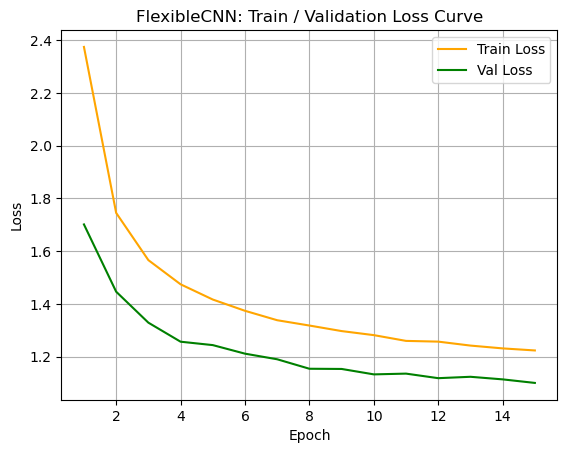

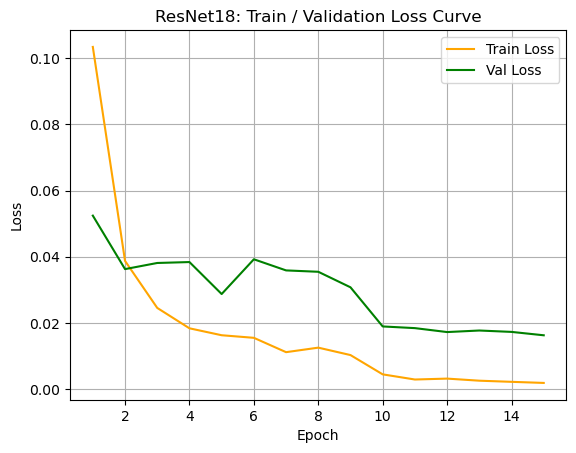

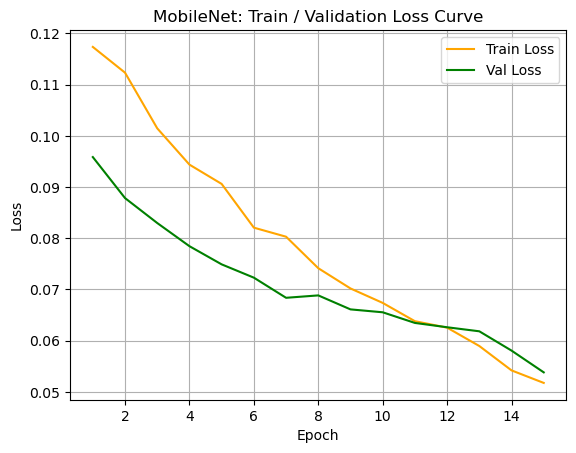

In [309]:
#make graphs about train / val loss
plt.figure()
plt.plot(range(1, n_epochs+1), train_loss2, color="orange", label="Train Loss")
plt.plot(range(1, n_epochs+1), val_loss2, color="green", label="Val Loss")
plt.title("FlexibleCNN: Train / Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
plt.plot(range(1, n_epochs+1), resnet_train_loss2, color="orange", label="Train Loss")
plt.plot(range(1, n_epochs+1), resnet_val_loss2, color="green", label="Val Loss")
plt.title("ResNet18: Train / Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

mobilenet_train_loss2, mobilenet_val_loss2

plt.figure()
plt.plot(range(1, n_epochs+1), mobilenet_train_loss2, color="orange", label="Train Loss")
plt.plot(range(1, n_epochs+1), mobilenet_val_loss2, color="green", label="Val Loss")
plt.title("MobileNet: Train / Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

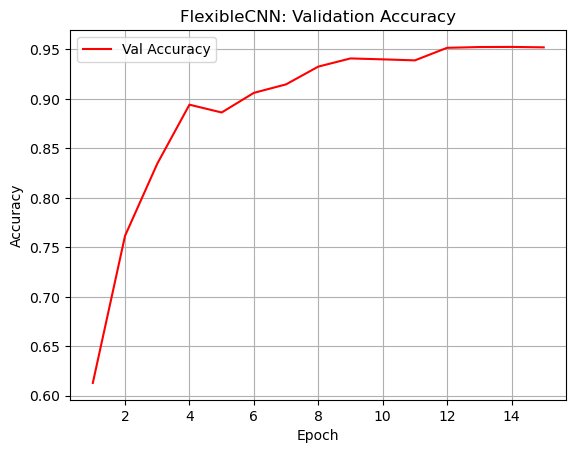

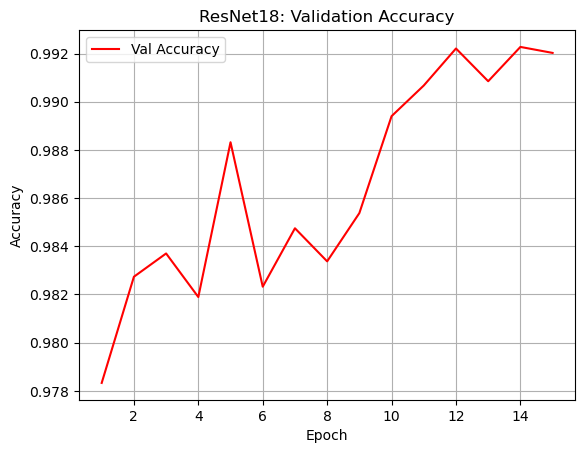

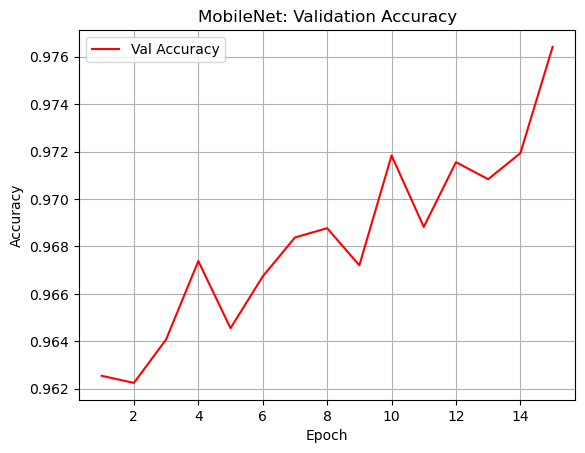

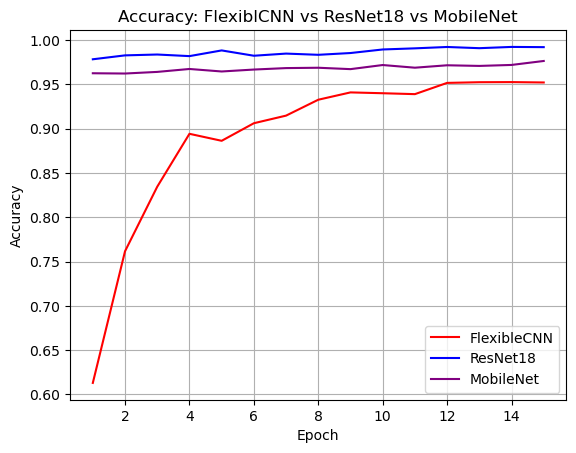

In [311]:
#make graphs about val accuracy
plt.figure()
plt.plot(range(1, n_epochs+1), accuracy2, color="red", label="Val Accuracy")
plt.title("FlexibleCNN: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
plt.plot(range(1, n_epochs+1), resnet_accuracy2, color="red", label="Val Accuracy")
plt.title("ResNet18: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
plt.plot(range(1, n_epochs+1), mobilenet_accuracy2, color="red", label="Val Accuracy")
plt.title("MobileNet: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, n_epochs+1), accuracy2, color="red", label="FlexibleCNN")
plt.plot(range(1, n_epochs+1), resnet_accuracy2, color="blue", label="ResNet18")
plt.plot(range(1, n_epochs+1), mobilenet_accuracy2, color="purple", label="MobileNet")
plt.title("Accuracy: FlexiblCNN vs ResNet18 vs MobileNet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# train / validation loss curve  FlexibleCNN2、ResNet18 Stage2、MobileNetV3 Stage2
# validation accuracy curve　FlexibleCNN2、ResNet18 Stage2、MobileNetV3 Stage2
# final test accuracy
# macro F1
# model size
# latency
# ResNet18 vs MobileNetV3 vs FlexibleCNN の比較

In [284]:
def compute_efficiency(
    model,
    model_name,
    device,
    input_size,
    test_accuracy,
    macro_f1
):
    
    warmup=20
    runs=100
    # =========================
    # Parameter count
    # =========================
    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


    # =========================
    # Model size
    # =========================
    with tempfile.NamedTemporaryFile(
        suffix=".pth",
        delete=False
    ) as f:
        path = f.name

    try:
        torch.save(
            model.state_dict(),
            path
        )

        model_size_mb = (
            os.path.getsize(path)
            / (1024 ** 2)
        )

    finally:
        os.remove(path)


    # =========================
    # Inference latency
    # =========================
    model.eval()

    dummy = torch.randn(
        1,
        3,
        input_size,
        input_size,
        device=device
    )

    times = []

    with torch.inference_mode():

        # Warmup
        for _ in range(warmup):
            _ = model(dummy)

        synchronize_device(device)


        # Measurement
        for _ in range(runs):

            synchronize_device(device)

            start = time.perf_counter()

            _ = model(dummy)

            synchronize_device(device)

            end = time.perf_counter()

            times.append(
                (end - start) * 1000
            )


    mean_latency = np.mean(times)
    median_latency = np.median(times)
    p95_latency = np.percentile(times, 95)


    return {
        "Model": model_name,
        "Input Size": input_size,
        "Accuracy": test_accuracy,
        "Macro F1": macro_f1,
        "Total Params": total_params,
        "Trainable Params": trainable_params,
        "Model Size (MB)": model_size_mb,
        "Mean Latency (ms)": mean_latency,
        "Median Latency (ms)": median_latency,
        "P95 Latency (ms)": p95_latency
    }


def synchronize_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize()

    elif device.type == "mps":
        torch.mps.synchronize()

In [287]:
results = []

# results.append(
#     compute_efficiency(
#         model=model1,
#         model_name="FlexibleCNN",
#         device=device,
#         input_size=128,
#         test_accuracy=flexible_cnn_test_accuracy1,
#         macro_f1=flexible_cnn_test_f1_1
#     )
# )

results.append(
    compute_efficiency(
        model=model2,
        model_name="FlexibleCNN2",
        device=device,
        input_size=128,
        test_accuracy=flexible_cnn_test_accuracy2,
        macro_f1=flexible_cnn_test_f1_2
    )
)


results.append(
    compute_efficiency(
        model=fine_tuned_resnet18_stage2,
        model_name="ResNet18",
        device=device,
        input_size=224,
        test_accuracy=resnet_test_accuracy,
        macro_f1=resnet_test_f1
    )
)

results.append(
    compute_efficiency(
        model=fine_tuned_mobilenet_stage2,
        model_name="MobileNetV3",
        device=device,
        input_size=224,
        test_accuracy=mobilenet_test_accuracy,
        macro_f1=mobilenet_test_f1
    )
)

df_efficiency = pd.DataFrame(results)

display(df_efficiency)

,Model,Input Size,Accuracy,Macro F1,Total Params,Trainable Params,Model Size (MB),Mean Latency (ms),Median Latency (ms),P95 Latency (ms)
0,FlexibleCNN2,128,[0.9547808170318604],[0.9615232348442078],267670,267670,1.025886,1.587111,1.477125,2.111596
1,ResNet18,224,[0.9902276992797852],[0.9912989139556885],11196006,8413222,42.783763,6.068143,5.857916,7.017331
2,MobileNetV3,224,[0.971501350402832],[0.9709445834159851],1556806,686246,6.064086,5.872049,5.497604,7.846996


In [13]:
image, true_label = test_dataset_for_pm[0]

result = predict_image(
    image=image,
    model=fine_tuned_resnet18_stage2,
    class_names=raw_dataset.classes,
    device=device,
    transform=test_transforms_for_pm
)

print("True class:")
print(raw_dataset.classes[true_label])

print("\nPredicted class:")
print(result["class_name"])

print(
    f'Confidence: {result["confidence"] * 100:.2f}%'
)


NameError: name 'fine_tuned_resnet18_stage2' is not defined

In [299]:
disease_database = {
  "Apple___Apple_scab": {
    "class_index": 0,
    "dataset_key": "Apple___Apple_scab",
    "plant": "Apple",
    "condition": "Apple scab",
    "status": "diseased",
    "symptoms": [
      "Olive-green to brown velvety leaf spots",
      "Dark scabby fruit lesions",
      "Premature leaf drop in severe cases"
    ],
    "cause": "Venturia inaequalis",
    "treatment": [
      "Remove or shred fallen leaves and infected fruit",
      "Improve airflow by pruning",
      "Consult local guidance before fungicide use"
    ],
    "prevention": [
      "Use resistant cultivars",
      "Reduce prolonged leaf wetness",
      "Sanitize fallen debris"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Apple___Black_rot": {
    "class_index": 1,
    "dataset_key": "Apple___Black_rot",
    "plant": "Apple",
    "condition": "Black rot",
    "status": "diseased",
    "symptoms": [
      "Purple-edged leaf spots with tan centers",
      "Dark fruit rot",
      "Branch cankers or dead bark"
    ],
    "cause": "Botryosphaeria obtusa (also called Diplodia seriata)",
    "treatment": [
      "Remove mummified fruit and dead or cankered wood",
      "Prune with clean tools",
      "Reduce tree stress"
    ],
    "prevention": [
      "Maintain tree vigor",
      "Avoid bark and fruit injury",
      "Remove dead tissue that may harbor the pathogen"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Apple___Cedar_apple_rust": {
    "class_index": 2,
    "dataset_key": "Apple___Cedar_apple_rust",
    "plant": "Apple",
    "condition": "Cedar-apple rust",
    "status": "diseased",
    "symptoms": [
      "Yellow to bright-orange leaf spots",
      "Dark dots within lesions",
      "Tube-like structures on leaf undersides"
    ],
    "cause": "Gymnosporangium species",
    "treatment": [
      "Remove heavily affected leaves when practical",
      "Inspect nearby junipers for rust galls",
      "Seek local fungicide guidance if needed"
    ],
    "prevention": [
      "Use resistant cultivars",
      "Reduce proximity to heavily infected junipers where practical",
      "Monitor during wet spring weather"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Apple___healthy": {
    "class_index": 3,
    "dataset_key": "Apple___healthy",
    "plant": "Apple",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Blueberry___healthy": {
    "class_index": 4,
    "dataset_key": "Blueberry___healthy",
    "plant": "Blueberry",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Cherry_(including_sour)___Powdery_mildew": {
    "class_index": 5,
    "dataset_key": "Cherry_(including_sour)___Powdery_mildew",
    "plant": "Cherry (including sour cherry)",
    "condition": "Powdery mildew",
    "status": "diseased",
    "symptoms": [
      "White or gray powdery growth",
      "Curled or distorted young leaves",
      "Reduced shoot growth"
    ],
    "cause": "Podosphaera species",
    "treatment": [
      "Remove badly infected tissue",
      "Improve airflow",
      "Use locally approved treatment only when necessary"
    ],
    "prevention": [
      "Avoid excessive nitrogen",
      "Prune for ventilation",
      "Monitor young foliage"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Cherry_(including_sour)___healthy": {
    "class_index": 6,
    "dataset_key": "Cherry_(including_sour)___healthy",
    "plant": "Cherry (including sour cherry)",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
    "class_index": 7,
    "dataset_key": "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "plant": "Corn (maize)",
    "condition": "Gray leaf spot",
    "status": "diseased",
    "symptoms": [
      "Long rectangular gray-to-tan lesions",
      "Lesions limited by veins",
      "Large areas of dead tissue in severe cases"
    ],
    "cause": "Cercospora zeae-maydis or Cercospora zeina",
    "treatment": [
      "Assess severity and crop stage",
      "Follow local residue and fungicide guidance",
      "Avoid irrigation that prolongs leaf wetness"
    ],
    "prevention": [
      "Use resistant hybrids",
      "Rotate crops where appropriate",
      "Manage infected residue"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Corn_(maize)___Common_rust_": {
    "class_index": 8,
    "dataset_key": "Corn_(maize)___Common_rust_",
    "plant": "Corn (maize)",
    "condition": "Common rust",
    "status": "diseased",
    "symptoms": [
      "Cinnamon-brown pustules",
      "Powdery spores",
      "Yellowing or drying under severe infection"
    ],
    "cause": "Puccinia sorghi",
    "treatment": [
      "Monitor disease progress",
      "Use local recommendations if treatment is justified",
      "Remove volunteer corn where practical"
    ],
    "prevention": [
      "Plant resistant hybrids",
      "Scout during cool humid periods",
      "Maintain balanced fertility"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Corn_(maize)___Northern_Leaf_Blight": {
    "class_index": 9,
    "dataset_key": "Corn_(maize)___Northern_Leaf_Blight",
    "plant": "Corn (maize)",
    "condition": "Northern corn leaf blight",
    "status": "diseased",
    "symptoms": [
      "Long cigar-shaped lesions",
      "Gray-green to tan color",
      "Lower leaves often affected first"
    ],
    "cause": "Exserohilum turcicum",
    "treatment": [
      "Evaluate severity and crop stage",
      "Follow local fungicide recommendations",
      "Manage residue and rotation"
    ],
    "prevention": [
      "Choose resistant hybrids",
      "Rotate away from corn",
      "Monitor high-risk fields"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Corn_(maize)___healthy": {
    "class_index": 10,
    "dataset_key": "Corn_(maize)___healthy",
    "plant": "Corn (maize)",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Grape___Black_rot": {
    "class_index": 11,
    "dataset_key": "Grape___Black_rot",
    "plant": "Grape",
    "condition": "Black rot",
    "status": "diseased",
    "symptoms": [
      "Tan leaf spots with dark margins",
      "Tiny black fruiting bodies",
      "Shriveled black berry mummies"
    ],
    "cause": "Guignardia bidwellii",
    "treatment": [
      "Remove mummified berries and infected debris",
      "Improve canopy airflow",
      "Follow local fungicide timing guidance"
    ],
    "prevention": [
      "Maintain an open canopy",
      "Remove overwintering mummies",
      "Monitor during warm wet periods"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Grape___Esca_(Black_Measles)": {
    "class_index": 12,
    "dataset_key": "Grape___Esca_(Black_Measles)",
    "plant": "Grape",
    "condition": "Esca (black measles)",
    "status": "diseased",
    "symptoms": [
      "Interveinal yellow or reddish-brown striping",
      "Dark berry spots",
      "Vine decline or sudden collapse"
    ],
    "cause": "A complex of wood-colonizing fungi",
    "treatment": [
      "Prune out severely affected wood",
      "Remove badly declining vines if advised",
      "Consult a viticulture specialist"
    ],
    "prevention": [
      "Protect pruning wounds",
      "Use clean propagation material",
      "Avoid trunk injury"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": {
    "class_index": 13,
    "dataset_key": "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "plant": "Grape",
    "condition": "Isariopsis leaf spot",
    "status": "diseased",
    "symptoms": [
      "Angular or irregular brown spots",
      "Leaf blighting",
      "Premature leaf drop"
    ],
    "cause": "Pseudocercospora vitis",
    "treatment": [
      "Remove heavily infected leaves and debris",
      "Improve canopy ventilation",
      "Seek local disease-management guidance"
    ],
    "prevention": [
      "Reduce leaf wetness",
      "Maintain an open canopy",
      "Sanitize infected debris"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Grape___healthy": {
    "class_index": 14,
    "dataset_key": "Grape___healthy",
    "plant": "Grape",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Orange___Haunglongbing_(Citrus_greening)": {
    "class_index": 15,
    "dataset_key": "Orange___Haunglongbing_(Citrus_greening)",
    "plant": "Orange (citrus)",
    "condition": "Huanglongbing (citrus greening)",
    "status": "diseased",
    "symptoms": [
      "Asymmetrical blotchy yellow mottling",
      "Small lopsided poorly colored fruit",
      "Twig dieback and tree decline"
    ],
    "cause": "Candidatus Liberibacter species spread by citrus psyllids",
    "treatment": [
      "Contact local plant-health authorities",
      "Do not move suspect plant material",
      "Follow official psyllid-management guidance"
    ],
    "prevention": [
      "Use certified disease-free stock",
      "Monitor for psyllids",
      "Follow quarantine regulations"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Peach___Bacterial_spot": {
    "class_index": 16,
    "dataset_key": "Peach___Bacterial_spot",
    "plant": "Peach",
    "condition": "Bacterial spot",
    "status": "diseased",
    "symptoms": [
      "Dark or water-soaked leaf spots",
      "Shot-hole appearance",
      "Sunken cracked fruit lesions"
    ],
    "cause": "Xanthomonas arboricola pv. pruni",
    "treatment": [
      "Avoid overhead irrigation",
      "Remove severely affected tissue where practical",
      "Use local bactericide guidance"
    ],
    "prevention": [
      "Use resistant cultivars",
      "Avoid excessive nitrogen and injury",
      "Use clean nursery stock"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Peach___healthy": {
    "class_index": 17,
    "dataset_key": "Peach___healthy",
    "plant": "Peach",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Pepper,_bell___Bacterial_spot": {
    "class_index": 18,
    "dataset_key": "Pepper,_bell___Bacterial_spot",
    "plant": "Bell pepper",
    "condition": "Bacterial spot",
    "status": "diseased",
    "symptoms": [
      "Water-soaked spots becoming brown or black",
      "Yellow halos or torn centers",
      "Raised scabby fruit lesions"
    ],
    "cause": "Xanthomonas species",
    "treatment": [
      "Remove severely affected plants",
      "Avoid handling wet foliage",
      "Follow local bactericide guidance"
    ],
    "prevention": [
      "Use disease-free seed or transplants",
      "Rotate away from pepper and tomato",
      "Sanitize tools and debris"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Pepper,_bell___healthy": {
    "class_index": 19,
    "dataset_key": "Pepper,_bell___healthy",
    "plant": "Bell pepper",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Potato___Early_blight": {
    "class_index": 20,
    "dataset_key": "Potato___Early_blight",
    "plant": "Potato",
    "condition": "Early blight",
    "status": "diseased",
    "symptoms": [
      "Brown target-like lesions",
      "Older leaves affected first",
      "Yellowing and premature defoliation"
    ],
    "cause": "Alternaria solani",
    "treatment": [
      "Remove badly infected foliage",
      "Maintain balanced fertility",
      "Use local fungicide guidance"
    ],
    "prevention": [
      "Rotate crops",
      "Use healthy seed potatoes",
      "Reduce plant stress and leaf wetness"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Potato___Late_blight": {
    "class_index": 21,
    "dataset_key": "Potato___Late_blight",
    "plant": "Potato",
    "condition": "Late blight",
    "status": "diseased",
    "symptoms": [
      "Dark water-soaked lesions",
      "White growth under humid conditions",
      "Stem or tuber rot"
    ],
    "cause": "Phytophthora infestans",
    "treatment": [
      "Remove infected material promptly",
      "Avoid overhead watering",
      "Contact local extension services quickly"
    ],
    "prevention": [
      "Use certified seed potatoes",
      "Destroy volunteer potatoes and cull piles",
      "Monitor regional alerts"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Potato___healthy": {
    "class_index": 22,
    "dataset_key": "Potato___healthy",
    "plant": "Potato",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Raspberry___healthy": {
    "class_index": 23,
    "dataset_key": "Raspberry___healthy",
    "plant": "Raspberry",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Soybean___healthy": {
    "class_index": 24,
    "dataset_key": "Soybean___healthy",
    "plant": "Soybean",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Squash___Powdery_mildew": {
    "class_index": 25,
    "dataset_key": "Squash___Powdery_mildew",
    "plant": "Squash",
    "condition": "Powdery mildew",
    "status": "diseased",
    "symptoms": [
      "White powdery patches",
      "Yellowing and browning leaves",
      "Reduced vigor"
    ],
    "cause": "Podosphaera xanthii or related fungi",
    "treatment": [
      "Remove badly infected leaves if practical",
      "Improve airflow",
      "Use approved treatment only as directed"
    ],
    "prevention": [
      "Plant resistant cultivars",
      "Provide good spacing and sunlight",
      "Scout regularly"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Strawberry___Leaf_scorch": {
    "class_index": 26,
    "dataset_key": "Strawberry___Leaf_scorch",
    "plant": "Strawberry",
    "condition": "Leaf scorch",
    "status": "diseased",
    "symptoms": [
      "Small purple spots",
      "Reddish-brown scorched appearance",
      "Reduced vigor"
    ],
    "cause": "Diplocarpon earlianum",
    "treatment": [
      "Remove infected leaves and debris",
      "Improve spacing and airflow",
      "Follow local strawberry guidance"
    ],
    "prevention": [
      "Use healthy planting material",
      "Avoid overhead irrigation",
      "Remove old infected debris"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Strawberry___healthy": {
    "class_index": 27,
    "dataset_key": "Strawberry___healthy",
    "plant": "Strawberry",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  },
  "Tomato___Bacterial_spot": {
    "class_index": 28,
    "dataset_key": "Tomato___Bacterial_spot",
    "plant": "Tomato",
    "condition": "Bacterial spot",
    "status": "diseased",
    "symptoms": [
      "Small dark water-soaked spots",
      "Yellow halos and leaf blight",
      "Raised scabby fruit lesions"
    ],
    "cause": "Xanthomonas species",
    "treatment": [
      "Remove severely affected tissue",
      "Avoid overhead irrigation",
      "Follow local bactericide guidance"
    ],
    "prevention": [
      "Use disease-free seed and transplants",
      "Rotate away from tomato and pepper",
      "Sanitize tools and stakes"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Early_blight": {
    "class_index": 29,
    "dataset_key": "Tomato___Early_blight",
    "plant": "Tomato",
    "condition": "Early blight",
    "status": "diseased",
    "symptoms": [
      "Target-like brown lesions",
      "Lower leaves affected first",
      "Yellowing and leaf death"
    ],
    "cause": "Alternaria solani",
    "treatment": [
      "Remove infected lower leaves",
      "Mulch and improve airflow",
      "Use local fungicide guidance"
    ],
    "prevention": [
      "Rotate crops",
      "Remove infected debris",
      "Avoid overhead watering"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Late_blight": {
    "class_index": 30,
    "dataset_key": "Tomato___Late_blight",
    "plant": "Tomato",
    "condition": "Late blight",
    "status": "diseased",
    "symptoms": [
      "Dark greasy or water-soaked lesions",
      "Rapid expansion in cool humid weather",
      "White growth on lesion undersides"
    ],
    "cause": "Phytophthora infestans",
    "treatment": [
      "Remove infected plants promptly",
      "Avoid overhead watering",
      "Contact local extension services"
    ],
    "prevention": [
      "Use healthy transplants",
      "Destroy volunteer tomatoes and potatoes",
      "Monitor disease alerts"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Leaf_Mold": {
    "class_index": 31,
    "dataset_key": "Tomato___Leaf_Mold",
    "plant": "Tomato",
    "condition": "Leaf mold",
    "status": "diseased",
    "symptoms": [
      "Pale yellow upper-surface spots",
      "Olive-gray velvety growth underneath",
      "Leaf curling and drop"
    ],
    "cause": "Passalora fulva",
    "treatment": [
      "Remove infected leaves",
      "Lower humidity and improve ventilation",
      "Use approved treatment if needed"
    ],
    "prevention": [
      "Use resistant varieties",
      "Space and prune for airflow",
      "Avoid wetting foliage"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Septoria_leaf_spot": {
    "class_index": 32,
    "dataset_key": "Tomato___Septoria_leaf_spot",
    "plant": "Tomato",
    "condition": "Septoria leaf spot",
    "status": "diseased",
    "symptoms": [
      "Numerous small circular spots",
      "Gray centers with dark borders",
      "Lower-leaf yellowing"
    ],
    "cause": "Septoria lycopersici",
    "treatment": [
      "Remove infected lower leaves",
      "Mulch and water at the base",
      "Use local fungicide guidance"
    ],
    "prevention": [
      "Rotate crops",
      "Remove infected debris",
      "Stake plants and avoid overhead watering"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Spider_mites Two-spotted_spider_mite": {
    "class_index": 33,
    "dataset_key": "Tomato___Spider_mites Two-spotted_spider_mite",
    "plant": "Tomato",
    "condition": "Two-spotted spider mite damage",
    "status": "pest",
    "symptoms": [
      "Fine pale stippling",
      "Bronzing or yellowing",
      "Fine webbing on undersides"
    ],
    "cause": "Tetranychus urticae",
    "treatment": [
      "Inspect leaf undersides",
      "Use water spray where appropriate",
      "Follow integrated pest-management guidance"
    ],
    "prevention": [
      "Avoid drought stress",
      "Inspect new plants",
      "Conserve beneficial predatory mites"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Target_Spot": {
    "class_index": 34,
    "dataset_key": "Tomato___Target_Spot",
    "plant": "Tomato",
    "condition": "Target spot",
    "status": "diseased",
    "symptoms": [
      "Brown circular lesions",
      "Concentric rings",
      "Leaf blighting and possible fruit lesions"
    ],
    "cause": "Corynespora cassiicola",
    "treatment": [
      "Remove infected leaves and debris",
      "Improve airflow",
      "Use local fungicide guidance"
    ],
    "prevention": [
      "Rotate crops",
      "Avoid overhead irrigation",
      "Use clean transplants"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
    "class_index": 35,
    "dataset_key": "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "plant": "Tomato",
    "condition": "Tomato yellow leaf curl virus",
    "status": "diseased",
    "symptoms": [
      "Upward leaf curling",
      "Yellowing and stunting",
      "Flower drop and reduced fruit set"
    ],
    "cause": "A begomovirus transmitted mainly by whiteflies",
    "treatment": [
      "Remove infected plants",
      "Manage whiteflies using IPM",
      "Dispose of infected material appropriately"
    ],
    "prevention": [
      "Use resistant varieties",
      "Use virus-free transplants",
      "Control weeds and volunteer hosts"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___Tomato_mosaic_virus": {
    "class_index": 36,
    "dataset_key": "Tomato___Tomato_mosaic_virus",
    "plant": "Tomato",
    "condition": "Tomato mosaic virus",
    "status": "diseased",
    "symptoms": [
      "Light and dark green mosaic pattern",
      "Leaf distortion or blistering",
      "Stunting and uneven fruit ripening"
    ],
    "cause": "Tomato mosaic virus, a tobamovirus",
    "treatment": [
      "Remove infected plants",
      "Disinfect tools and wash hands",
      "Avoid tobacco contact before handling plants"
    ],
    "prevention": [
      "Use resistant cultivars and certified seed",
      "Sanitize equipment",
      "Do not propagate symptomatic plants"
    ],
    "warning": "Image-based classification is not a definitive diagnosis. Confirm important cases with a local extension service or plant-health professional."
  },
  "Tomato___healthy": {
    "class_index": 37,
    "dataset_key": "Tomato___healthy",
    "plant": "Tomato",
    "condition": "Healthy",
    "status": "healthy",
    "symptoms": [
      "No characteristic disease lesions are visible",
      "Leaf appearance is broadly consistent with a healthy plant"
    ],
    "cause": "No specific disease was detected by the image classifier.",
    "treatment": [
      "No disease treatment is recommended from this image alone",
      "Continue normal care and routine inspection"
    ],
    "prevention": [
      "Maintain good airflow",
      "Avoid prolonged leaf wetness",
      "Inspect regularly for new symptoms"
    ],
    "warning": "A healthy prediction does not rule out early, hidden, root, or non-visible problems."
  }
}

In [304]:
image, true_label = test_dataset_for_pm[0]

result = predict_image(
    image=image,
    model=fine_tuned_resnet18_stage2,
    class_names=raw_dataset.classes,
    device=device
)
diagnosis = build_diagnosis(
    disease_database,
    result,
)

explanation = generate_explanation(diagnosis)
print(explanation)

{'plant': 'Cherry (including sour)', 'disease': 'Powdery mildew', 'confidence': 0.7968568801879883, 'symptoms': ['White or gray powdery growth', 'Curled or distorted young leaves', 'Reduced shoot growth'], 'cause': 'Podosphaera species', 'treatment': ['Remove badly infected tissue', 'Improve airflow', 'Use locally approved treatment only when necessary'], 'prevention': ['Avoid excessive nitrogen', 'Prune for ventilation', 'Monitor young foliage']}


In [305]:
#question classification with BERT
df = pd.read_csv("plant_intent_dataset_500.csv")

display(df.head())
print(df["label"].value_counts())
print(df.groupby(["label", "split"]).size())

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "validation"]
test_df = df[df["split"] == "test"]

train_texts = train_df.tolist()
val_texts = val_df.tolist()
test_texts = test_df.tolist()
labels = df["label"].tolist()

FileNotFoundError: [Errno 2] No such file or directory: 'plant_intent_dataset_500.csv'

In [307]:
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer, DistilBertForSequenceClassification
import transformers

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5,
    id2label={
        0: "symptoms",
        1: "cause",
        2: "treatment",
        3: "prevention",
        4: "general"
    },
    label2id={
        "symptoms": 0,
        "cause": 1,
        "treatment": 2,
        "prevention": 3,
        "general": 4
    }
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
class QuestionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    
    def __len__(self):
        return len(text)
    
    def __initget__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        encoding = self.tokenizer(text, truncation=True, max_length=512, return_tensors="pt")
        encoding["labels"] = torch.tensor(label, dtype=torch.long)
        
        return encoding

train_text_dataset = QuestionDataset(train_texts, labels, tokenizer)
val_text_dataset = QuestionDataset(val_texts, labels, tokenizer)
test_text_dataset = QuestionDataset(test_texts, labels, tokenizer)

In [ ]:
data_collator = transformers.DataCollatorWithPadding(tokenizer=tokenizer)
batch_size = 32

train_text_loader = DataLoader(
    dataset=train_text_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=data_collator
)

val_text_loader = DataLoader(
    dataset=val_text_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=data_collator
)

test_text_loader = DataLoader(
    dataset=test_text_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=data_collator
)


In [ ]:
def train_loop_for_bert(model, train_loader, val_loader, optimizer, loss_function, device, n_epochs):   
    
    model.to(device)
    num_classes = model.config.num_labels
    val_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    val_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
    val_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
    val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
    epoch_loop = tqdm(range(n_epochs), desc="Training Progress")
    
    for epoch in range(n_epochs):
        model.train()
        train_loss_epoch = 0
        train_inner_loop = tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{n_epochs} Training", leave=False
        )
        for batch in train_inner_loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_function(logits, labels)
            train_loss_epoch += loss.item() * len(labels)
            loss.backward()
            optimizer.step()
            
            train_inner_loop.set_postfix(loss=loss.item())
            
        train_loss_epoch /= len(train_loader.dataset)
        
        model.eval()
        val_loss_epoch = 0
        val_inner_loop = tqdm(
            val_loader, desc=f"Epoch {epoch+1}/{n_epochs} Validation", leave=False
        )
        
        with torch.no_grad():
            for batch in val_inner_loop:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                val_loss = loss_function(logits, labels)
                val_loss_epoch += val_loss.item() * len(labels)

                preds = torch.argmax(logits, dim=-1)
                val_accuracy.update(preds, labels)
                val_precision.update(preds, labels)
                val_recall.update(preds, labels)
                val_f1.update(preds, labels)
                   
        val_loss_epoch /= len(val_loader.dataset)

        epoch_acc = val_accuracy.compute()
        epoch_prec = val_precision.compute()
        epoch_recall = val_recall.compute()
        epoch_f1 = val_f1.compute()

        val_accuracy.reset()
        val_precision.reset()
        val_recall.reset()
        val_f1.reset()

        epoch_loop.set_postfix(
            train_loss=f"{train_loss_epoch:.4f}",
            val_loss=f"{val_loss_epoch:.4f}",
            val_acc=f"{epoch_acc:.4f}",
        )

        tqdm.write(
            f"Epoch {epoch+1} Metrics -> Val Acc: {epoch_acc:.4f}, Val F1: {epoch_f1:.4f}"
        )
        
    print("\n--- Training complete ---")

    final_results = {
        "val_accuracy": epoch_acc.item(),
        "val_precision": epoch_prec.item(),
        "val_recall": epoch_recall.item(),
        "val_f1": epoch_f1.item(),
    }

    return model, final_results

In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(bert_model.parameters(), lr=5e-5)
n_epochs = 5

fine_tuned_bert, train_results = train_loop_for_bert(
    model=bert_model,
    train_loader=train_text_loader, 
    val_loader=val_text_loader, 
    optimizer=optimizer, 
    loss_function=loss_function, 
    device=device, 
    n_epochs=n_epochs
)

In [ ]:
def evaluate_bert(model, test_loader, device, loss_function):
    model.to(device)
    model.eval()
    num_classes = model.config.num_labels
    
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes
    ).to(device)

    precision = torchmetrics.Precision(
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).to(device)

    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).to(device)

    f1 = torchmetrics.F1Score(
        task="multiclass",
        num_classes=num_classes,
        average="macro"
    ).to(device)

    running_loss = 0.0
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            loss = loss_function(logits, labels)
            running_loss += loss.item() * len(labels)
            
            predictions = logits.argmax(dim=1)
            
            accuracy.update(predictions, labels)
            precision.update(predictions, labels)
            recall.update(predictions, labels)
            f1.update(predictions, labels)
            
    test_loss = running_loss / len(test_loader.dataset)
        
    results = {
        "test_loss": test_loss,
        "test_accuracy": accuracy.compute().item(),
        "test_precision": precision.compute().item(),
        "test_recall": recall.compute().item(),
        "test_f1": f1.compute().item()
    }
    
    print(f"Test Loss: {results['test_loss']}, Test Accuracy: {results['test_accuracy']}, Test Precision: {results['test_precision']}, Test Recall: {results['test_recall']}, Test F1: {results['test_f1']}")
        
    return results 

In [ ]:
test_results = evaluate_bert(
    model=fine_tuned_bert, 
    test_loader=test_text_loader, 
    device=device, 
    loss_function=loss_function
)

In [ ]:
# def predict_image(image_path, model, transform, class_names, device):
#     image = Image.open(image_path).convert("RGB")
#     image = transform(image).unsqueeze(0).to(device)

#     model.eval()
#     with torch.no_grad():
#         outputs = model(image)
#         probabilities = torch.softmax(outputs, dim=1)
#         confidence, predicted_idx = probabilities.max(1)

#     predicted_idx = predicted_idx.item()
#     confidence = confidence.item()

#     return {
#         "class_index": predicted_idx,
#         "class_name": class_names[predicted_idx],
#         "confidence": confidence
#     }

image_result = predict_image(
    image_path="sample_leaf.jpg",
    model=fine_tuned_bert,
    transform=test_transforms,
    class_names=raw_dataset.classes,
    device=device
)

diagnosis = build_diagnosis(disease_database, image_result)

In [ ]:
def predict_intent(question, model, tokenizer, device):
    model.eval()
    encoded = tokenizer(
        question, 
        truncation=True, 
        max_length=512, 
        return_tensors="pt"
    )
    
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids, 
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        confidence, predicted_ids = probabilities.max(1)
    
    predicted_ids = predicted_ids.item()
    confidence = confidence.item()
    
    return {
        "intent_id": predicted_ids,
        "intent": model.config.id2label[predicted_id],
        "confidence": confidence,
        "probabilities": probabilities.squeeze(0).cpu()
    }

In [ ]:
def answer_user_question(question, image_result, bert_model, tokenizer, disease_database, device):
    intent_result = predict_intent(
        question=question,
        model=bert_model,
        tokenizer=tokenizer,
        device=device
    )

    class_name = image_result["class_name"]
    intent = intent_result["intent"]

    disease_info = disease_database[class_name]

    if intent == "general":
        answer = (
            f"The predicted condition is "
            f"{disease_info['condition']}. "
            f"{disease_info['warning']}"
        )
    else:
        answer = disease_info[intent]

        if isinstance(answer, list):
            answer = "\n".join(
                f"- {item}"
                for item in answer
            )

    return {
        "question": question,
        "intent": intent,
        "intent_confidence": intent_result["confidence"],
        "answer": answer
    }

In [ ]:
question = "How can I treat this disease?"

intent_result = predict_intent(
    question=question,
    model=fine_tuned_bert,
    tokenizer=tokenizer,
    device=device
)

print(intent_result)

In [ ]:
response = answer_user_question(
    question="How can I treat this disease?",
    image_result=result,
    bert_model=fine_tuned_bert,
    tokenizer=tokenizer,
    disease_database=disease_database,
    device=device
)

print(response["answer"])

In [ ]:
fine_tuned_bert.save_pretrained(
    "models/plant_intent_distilbert"
)

tokenizer.save_pretrained(
    "models/plant_intent_distilbert"
)

In [103]:
# class PlantDiseaseDataset(Dataset):
#     def __init__(self, image_paths, labels, transforms=None):
#         self.image_paths = image_paths
#         self.transforms = transforms
#         self.labels = labels
    
#     def __len__(self):
#         return len(labels)
    
#     def __getitem(self, idx):
#         image_path = self.images[idx]
#         label = self.labels[idx]
        
#         image = Image.open(image_path).convert("RGB")
        
#         if self.transforms:
#             image = self.transforms(image)
        
#         return image, label
        

In [ ]:
train / validation loss curve
validation accuracy curve
final test accuracy
macro F1
model size
latency
ResNet18 vs MobileNetV3 vs FlexibleCNN の比較